# Individual Policy Training F

This notebook trains the individual forward-simulation policies. This is not the meta policy.

It trains three separate PPO policies with one shared implementation:

- `lr_calculation`: selects read/retrieve mode, decision boundary, and feature slots.
- `lr_heuristic`: selects decision boundary and feature slots; there is no read/retrieve distinction.
- `dt_traversal`: selects decision boundary only.

Each environment includes the same five context values plus the raw previous five probabilities of being correct and raw previous five decision times. Missing history at the start of an episode is filled with `-1`.

## Observation And Action Spaces

Common observation prefix for all strategies:

1. normalized decision noise
2. normalized memory retrieval threshold
3. normalized opportunity cost
4. whether explanation is currently shown
5. episode progress
6. previous five probabilities assigned to the correct label, padded with `-1`
7. previous five prediction times, scaled by `/60` and padded with `-1`

The feature-selecting strategies use per-episode randomized feature slots. The environment maps those slots back to actual feature indices before calling the cognitive strategy and stores both slot-level and actual-feature selections during evaluation.

In [1]:
from dataclasses import asdict
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "rl_agents":
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

WindowsPath('c:/Users/Louth/Desktop/xaikit-test stage 3/CoXAM')

In [2]:
from rl_agents.individual_policy_training_f import (
    STRATEGIES,
    StrategyTrainingConfig,
    evaluate_strategy_policy,
    default_parameter_sweep_values,
    feature_selection_sweep_summary,
    load_all_strategy_policies,
    load_strategy_bundles,
    load_strategy_policy,
    plot_parameter_sweep,
    summarize_parameter_sweep,
    sweep_strategy_parameters,
    plot_strategy_evaluations,
    strategy_observation_action_summary,
    summarize_strategy_evaluations,
    train_all_strategy_policies,
    train_strategy_policy,
)



## Configure Training

In [3]:
strategy_config = StrategyTrainingConfig(
    data_dir=str(ROOT / "datasets"),
    output_root=str(ROOT / "outputs" / "unified_strategy_policy"),
    run_name="unified_strategy_demo",
    total_timesteps=3e5,
    n_envs=4,
    instances_per_episode=40,
    max_features=6,
    explanation_shown_ratio=0.5,
    decision_boundary_bins=5,
    decision_boundary_min=0.6,
    decision_boundary_max=1.8,
    decision_noise_min=0.3,
    decision_noise_max=0.7,
    memory_recall_threshold_min=-5.0,
    memory_recall_threshold_max=2.0,
    opportunity_cost_min=0.0,
    opportunity_cost_max=0.02,
    memory_recall_noise=0.5,
    retrieval_candidate_count=3,
    simulation_sample_count=16,
    history_window=5,
    randomize_feature_order_per_episode=True,
    seed=123,
)

display(strategy_observation_action_summary(strategy_config))
strategy_config

,strategy_name,observation_space,observation_contents,action_space,action_contents
0,lr_calculation,"Box(33, low=-1, high=1)",5 context values + previous 5 probabilities + ...,"MultiDiscrete([2, 5, 2, 2, 2, 2, 2, 2])","read/retrieve mode, decision-boundary bin, shu..."
1,lr_heuristic,"Box(27, low=-1, high=1)",5 context values + previous 5 probabilities + ...,"MultiDiscrete([5, 2, 2, 2, 2, 2, 2])","decision-boundary bin, shuffled feature-slot m..."
2,dt_traversal,"Box(21, low=-1, high=1)",5 context values + previous 5 probabilities + ...,Discrete(5),decision-boundary bin only


StrategyTrainingConfig(data_dir='c:\\Users\\Louth\\Desktop\\xaikit-test stage 3\\CoXAM\\datasets', output_root='c:\\Users\\Louth\\Desktop\\xaikit-test stage 3\\CoXAM\\outputs\\unified_strategy_policy', run_name='unified_strategy_demo', strategy_name='lr_calculation', total_timesteps=300000.0, n_envs=4, instances_per_episode=40, max_features=6, explanation_shown_ratio=0.5, seed=123, learning_rate=0.0003, gamma=0.85, ent_coef=0.01, n_steps=512, batch_size=256, decision_boundary_bins=5, decision_boundary_min=0.6, decision_boundary_max=1.8, decision_noise_min=0.3, decision_noise_max=0.7, memory_recall_threshold_min=-5.0, memory_recall_threshold_max=2.0, opportunity_cost_min=0.0, opportunity_cost_max=0.02, memory_recall_noise=0.5, retrieval_candidate_count=3, simulation_sample_count=16, read_seconds_per_item=1.0, mental_calculation_seconds=0.0, displayed_significant_figures=2, feature_cost=0.002, illegal_read_penalty=-1.0, dt_depth=2, history_window=5, randomize_feature_order_per_episode=Tr

## Check Available Bundles

In [4]:
bundles = load_strategy_bundles(Path(strategy_config.data_dir), strategy_config)
pd.DataFrame([
    {"app_id": b.app_id, "model_name": b.model_name, "n_instances": len(b.instance_ids)}
    for b in bundles
])

Skipping german_credit/xgboost: No logistic regression explanation found for appId: german_credit and variant: dense
Skipping diabetes/xgboost: No logistic regression explanation found for appId: diabetes and variant: dense


,app_id,model_name,n_instances
0,adult,xgboost,120
1,forest_cover,xgboost,120
2,wine_quality,mlp,400
3,mushrooms,mlp,400
4,adult,mlp,400
5,forest_cover,mlp,400
6,breast_cancer,mlp,400
7,breast_cancer,xgboost,400
8,wine_binary,mlp,130
9,wine_binary,xgboost,130


## Load Or Train Selected Policies

Set `SELECTED_STRATEGIES` to the individual forward policies you want to load/train. Set `REUSE_SAVED_MODELS = True` to evaluate existing `final_model.zip` files without retraining. Set it to `False` when you intentionally want a fresh PPO training run.


In [ ]:
SELECTED_STRATEGIES = [
    "lr_calculation",
    "lr_heuristic",
    "dt_traversal",
]
# Examples:
# SELECTED_STRATEGIES = ["dt_traversal"]
# SELECTED_STRATEGIES = ["lr_calculation", "dt_traversal"]

invalid_strategies = sorted(set(SELECTED_STRATEGIES) - set(STRATEGIES))
if invalid_strategies:
    raise ValueError(f"Unknown strategy name(s): {invalid_strategies}; expected one of {STRATEGIES}")

REUSE_SAVED_MODELS = False
MODEL_FILENAME = "final_model.zip"

strategy_results = {}
for strategy_name in SELECTED_STRATEGIES:
    config = StrategyTrainingConfig(**{**asdict(strategy_config), "strategy_name": strategy_name})
    if REUSE_SAVED_MODELS:
        strategy_results[strategy_name] = load_strategy_policy(
            config,
            model_filename=MODEL_FILENAME,
            device="cpu",
        )
    else:
        strategy_results[strategy_name] = train_strategy_policy(config)

pd.DataFrame([
    {
        "strategy_name": name,
        "run_dir": str(run_dir),
        "model_path": str(run_dir / "models" / MODEL_FILENAME),
        "n_bundles": len(strategy_bundles),
    }
    for name, (_model, run_dir, strategy_bundles) in strategy_results.items()
])


Skipping german_credit/xgboost: No logistic regression explanation found for appId: german_credit and variant: dense
Skipping diabetes/xgboost: No logistic regression explanation found for appId: diabetes and variant: dense
Using cpu device
Eval num_timesteps=2048, episode_reward=-5.54 +/- 2.11
Episode length: 40.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 40       |
|    mean_reward     | -5.54    |
| time/              |          |
|    total_timesteps | 2048     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 40       |
|    ep_rew_mean     | 3.27     |
| time/              |          |
|    fps             | 137      |
|    iterations      | 1        |
|    time_elapsed    | 14       |
|    total_timesteps | 2048     |
---------------------------------
Eval num_timesteps=4096, episode_reward=23.14 +/- 5.08
Episode length: 40

## Optional Single-Strategy Iteration

Use this cell instead of the all-strategy cell when you want a faster iteration loop.

In [ ]:
# one_config = StrategyTrainingConfig(**{**asdict(strategy_config), "strategy_name": "lr_calculation"})
# one_model, one_run_dir, one_bundles = train_strategy_policy(one_config)
# one_eval_df = evaluate_strategy_policy(one_model, one_bundles, one_config, n_episodes=50)
# one_eval_df.head()

## Evaluate And Visualize Trained Policies

This section works whether the policies were just trained or loaded from disk. It saves per-step evaluation rows to each strategy's `metrics/evaluation.csv` and shared comparison plots to `<run_name>/strategy_plots`.


,strategy_name,chosen_mode,with_explanation,n_rows,mean_reward,mean_prob_correct,mean_pred_time,mean_selected_features,mean_decision_boundary,accuracy,illegal_action_rate
0,dt_traversal,retrieve,False,2000,0.485248,0.504047,1.810676,0.000000,1.039950,0.457000,0.0
1,dt_traversal,retrieve,True,2000,0.614837,0.767000,16.913349,0.000000,1.319100,0.861500,0.0
2,lr_calculation,read,True,1989,0.644872,0.743402,11.330196,3.417295,1.057315,0.801408,0.0
3,lr_calculation,retrieve,False,2000,0.463659,0.500855,4.168694,0.353500,0.613650,0.473000,0.0
4,lr_calculation,retrieve,True,11,0.491541,0.586490,5.657073,1.090909,0.600000,0.636364,0.0
5,lr_heuristic,retrieve,False,2000,0.539655,0.576731,4.255200,1.443500,0.791100,0.621500,0.0
6,lr_heuristic,retrieve,True,2000,0.538824,0.576821,4.218164,1.414500,0.811500,0.605000,0.0


Saved 4 plot(s) to c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\strategy_plots


,episode,step,reward,app_id,model_name,strategy_name,chosen_mode,with_explanation,true_label,predicted_class,...,info_retrieve_time,info_decision_time,info_expected_time,info_path_categorical_decisions,info_path_numeric_decisions,info_path_top_leaf,info_path_top_leaf_count,info_path_n_leaves_reached,info_refresh_feature_count,info_refresh_thr_key_count
0,0,0,0.954817,breast_cancer,xgboost,lr_calculation,read,True,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1,0.953408,breast_cancer,xgboost,lr_calculation,read,True,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2,0.508063,breast_cancer,xgboost,lr_calculation,retrieve,False,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,3,0.448238,breast_cancer,xgboost,lr_calculation,retrieve,False,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,4,0.944353,breast_cancer,xgboost,lr_calculation,read,True,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


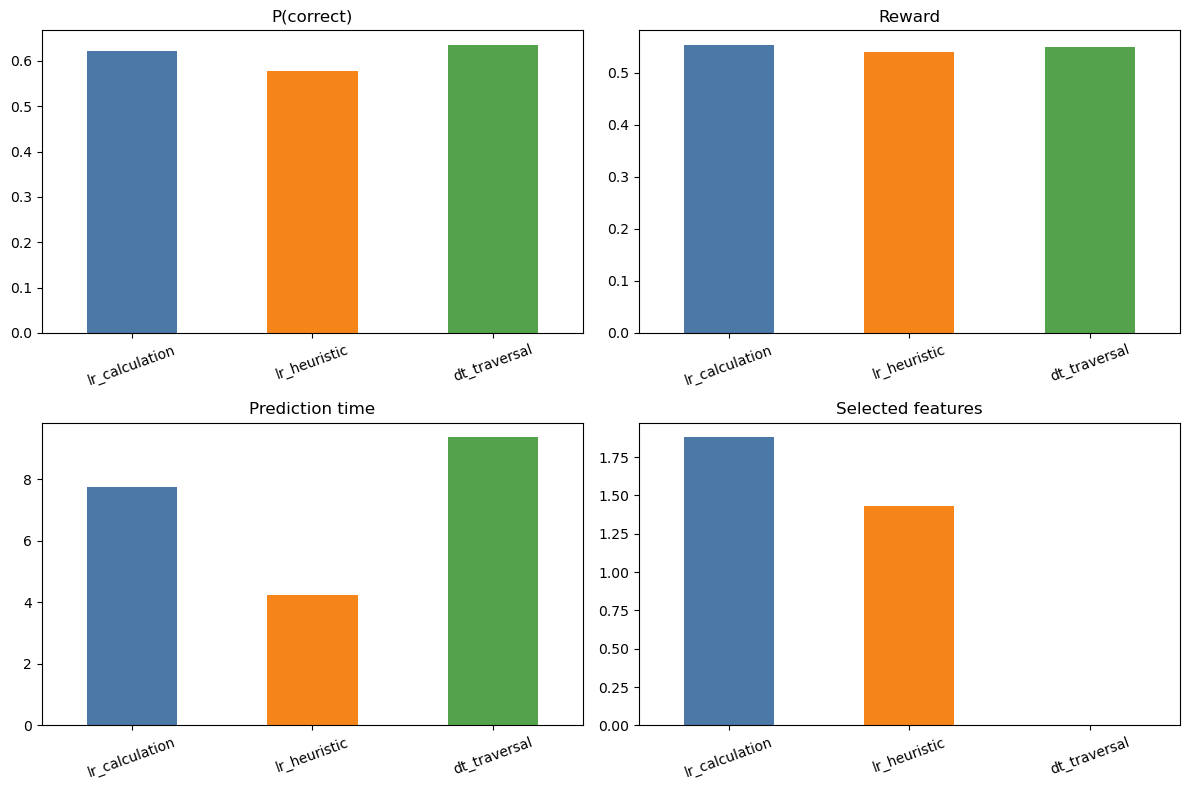

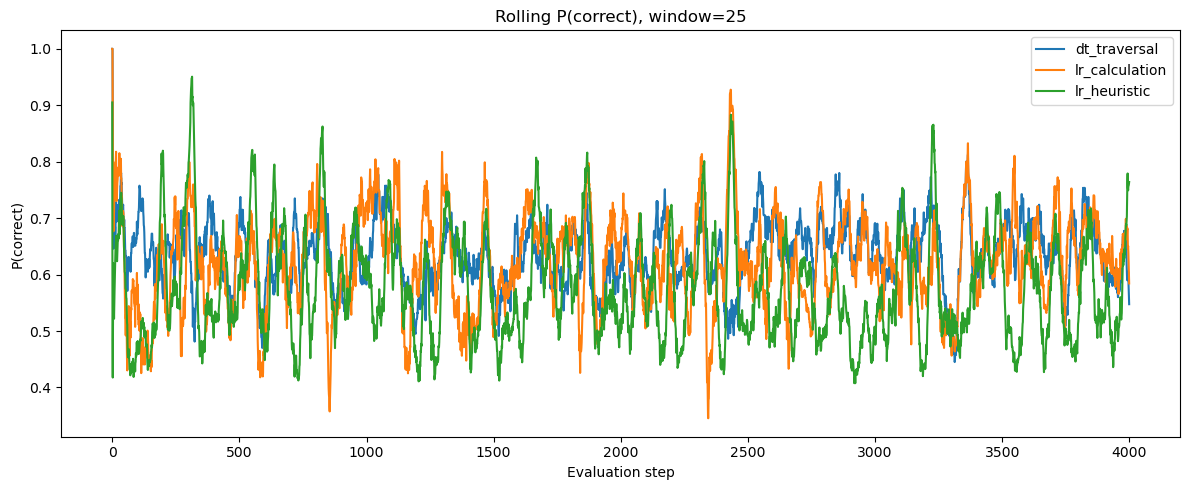

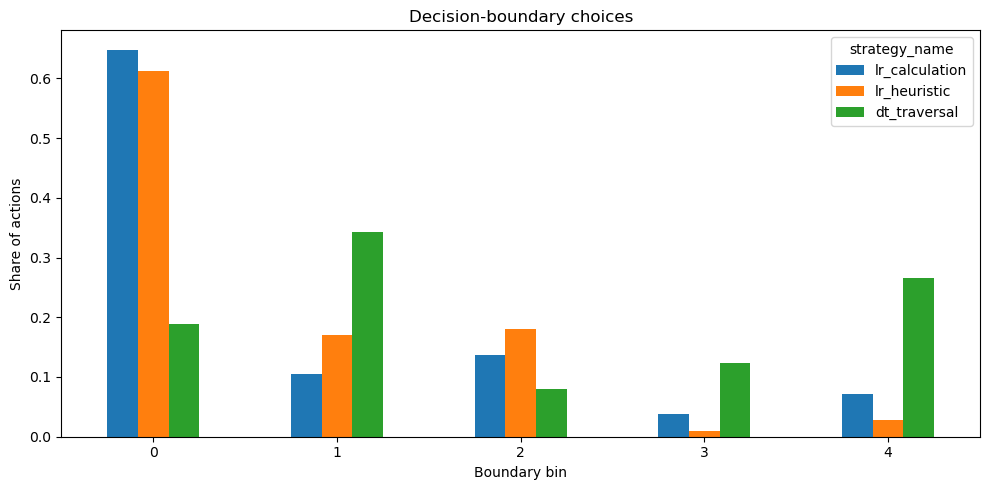

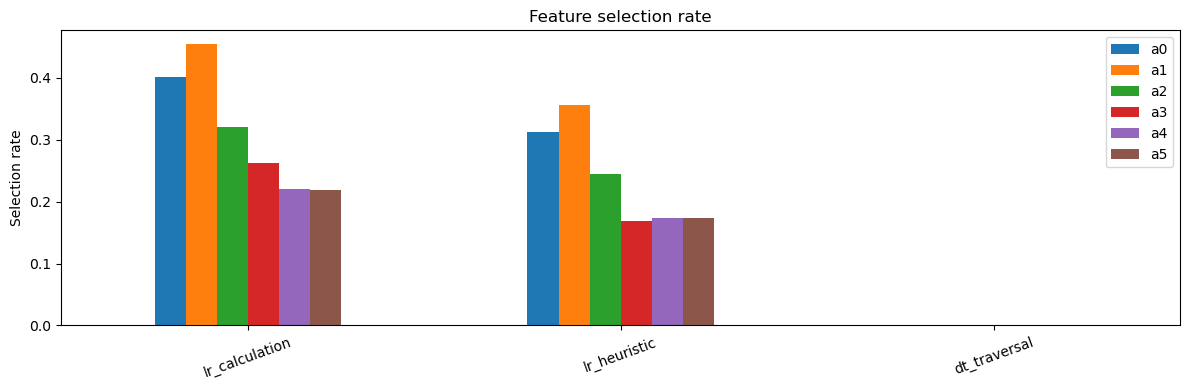

In [ ]:
evaluation_tables = {}

for strategy_name, (model, run_dir, strategy_bundles) in strategy_results.items():
    config = StrategyTrainingConfig(**{**asdict(strategy_config), "strategy_name": strategy_name})
    eval_df = evaluate_strategy_policy(
        model,
        strategy_bundles,
        config,
        n_episodes=100,
        deterministic=True,
        sample_parameters=True,
    )
    eval_path = run_dir / "metrics" / "evaluation.csv"
    eval_df.to_csv(eval_path, index=False)
    evaluation_tables[strategy_name] = eval_df

summary_df = summarize_strategy_evaluations(evaluation_tables)
display(summary_df)

combined_eval_df = pd.concat(evaluation_tables.values(), ignore_index=True)
plot_dir = Path(strategy_config.output_root) / (strategy_config.run_name or "latest") / "strategy_plots"
figures = plot_strategy_evaluations(evaluation_tables, output_dir=plot_dir, rolling_window=25)
print(f"Saved {len(figures)} plot(s) to {plot_dir}")

display(combined_eval_df.head())


## Parameter Sensitivity Sweeps

These sweeps reuse the loaded/trained policies and evaluate them under fixed values of one cognitive parameter at a time. Unspecified parameters are held at the midpoint of their configured range, so each curve isolates one parameter.


In [ ]:
SWEEP_EPISODES = 25
sweep_values = {
    "decision_noise": [0.3, 0.35, 0.4, 0.45, 0.5],
    "opportunity_cost": [0.0, 0.005, 0.01, 0.015, 0.02],
    "memory_recall_threshold": [-1.0, -0.25, 0.5, 1.25, 2.0],
}

sweep_df = sweep_strategy_parameters(
    strategy_results,
    strategy_config,
    sweep_values=sweep_values,
    n_episodes=SWEEP_EPISODES,
    deterministic=True,
)

sweep_dir = Path(strategy_config.output_root) / (strategy_config.run_name or "latest") / "parameter_sweeps"
sweep_dir.mkdir(parents=True, exist_ok=True)
sweep_df.to_csv(sweep_dir / "parameter_sweep_rows.csv", index=False)

sweep_summary_df = summarize_parameter_sweep(sweep_df)
sweep_feature_df = feature_selection_sweep_summary(sweep_df)
sweep_summary_df.to_csv(sweep_dir / "parameter_sweep_summary.csv", index=False)
sweep_feature_df.to_csv(sweep_dir / "parameter_sweep_feature_selection.csv", index=False)

display(sweep_summary_df.head(15))
print(f"Saved sweep data to {sweep_dir}")


,sweep_parameter,sweep_value,strategy_name,n_rows,mean_reward,mean_prob_correct,mean_pred_time,mean_selected_features,mean_decision_boundary,accuracy,illegal_action_rate
0,decision_noise,0.30,dt_traversal,1000,0.594389,0.680625,8.623609,0.000,0.8265,0.631,0.0
1,decision_noise,0.30,lr_calculation,1000,0.542512,0.646789,10.017533,2.051,0.7656,0.639,0.0
2,decision_noise,0.30,lr_heuristic,1000,0.569382,0.609360,3.777977,1.099,0.7437,0.669,0.0
3,decision_noise,0.35,dt_traversal,1000,0.583616,0.669312,8.569687,0.000,0.8568,0.628,0.0
4,decision_noise,0.35,lr_calculation,1000,0.542339,0.638448,9.215695,1.976,0.7860,0.644,0.0
5,decision_noise,0.35,lr_heuristic,1000,0.570260,0.611948,3.924612,1.221,0.7245,0.660,0.0
6,decision_noise,0.40,dt_traversal,1000,0.574186,0.661312,8.712683,0.000,0.9051,0.630,0.0
7,decision_noise,0.40,lr_calculation,1000,0.543454,0.632889,8.561511,1.910,0.7986,0.643,0.0
8,decision_noise,0.40,lr_heuristic,1000,0.570866,0.613360,3.998227,1.256,0.7431,0.670,0.0
9,decision_noise,0.45,dt_traversal,1000,0.560099,0.649656,8.955719,0.000,0.9726,0.630,0.0


Saved sweep data to c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\parameter_sweeps


Saved 12 sweep plot(s) to c:\Users\Louth\Desktop\xaikit-test stage 3\CoXAM\outputs\unified_strategy_policy\unified_strategy_demo\parameter_sweeps\plots


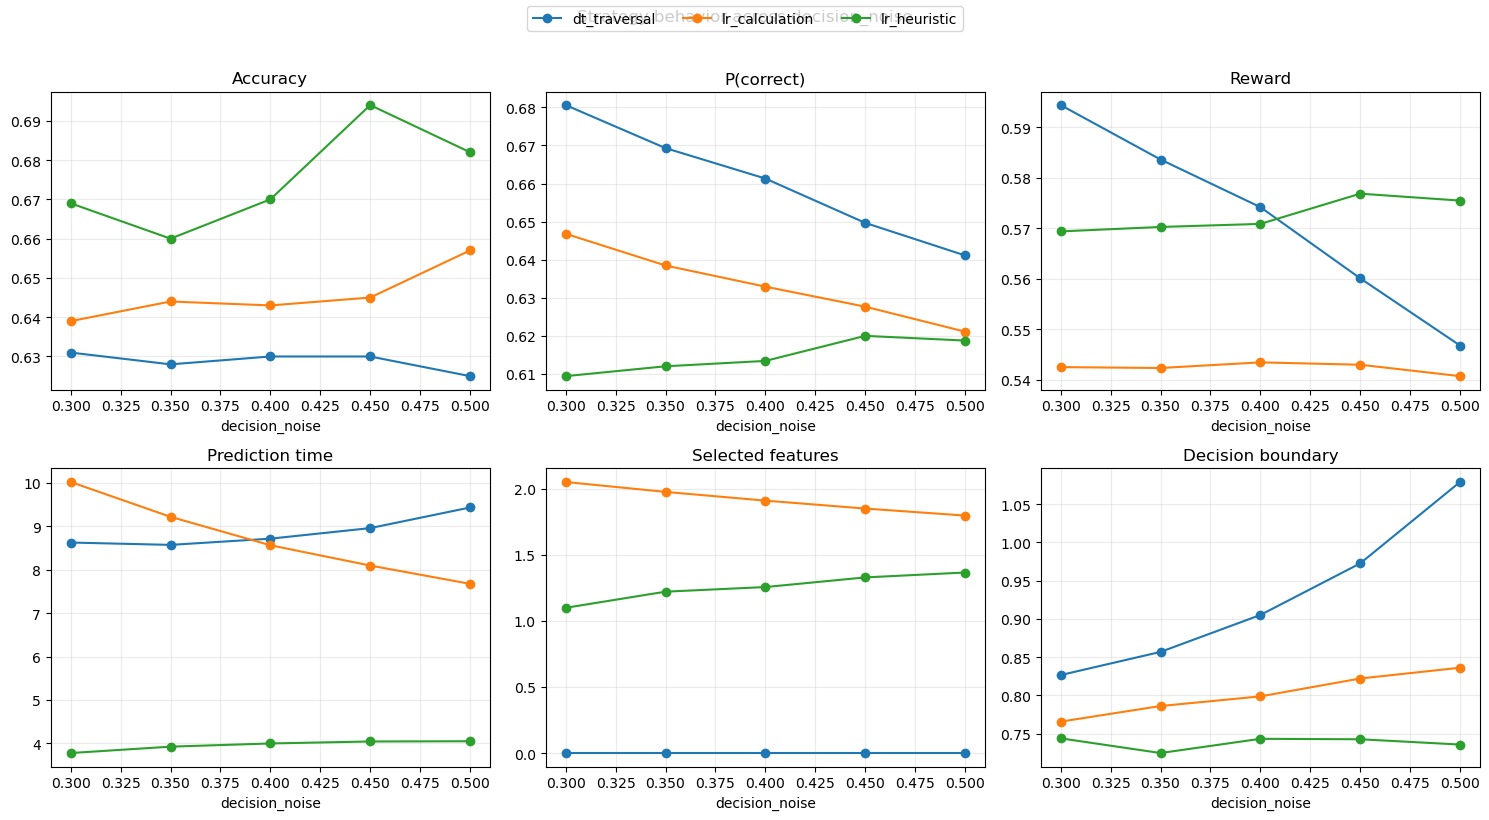

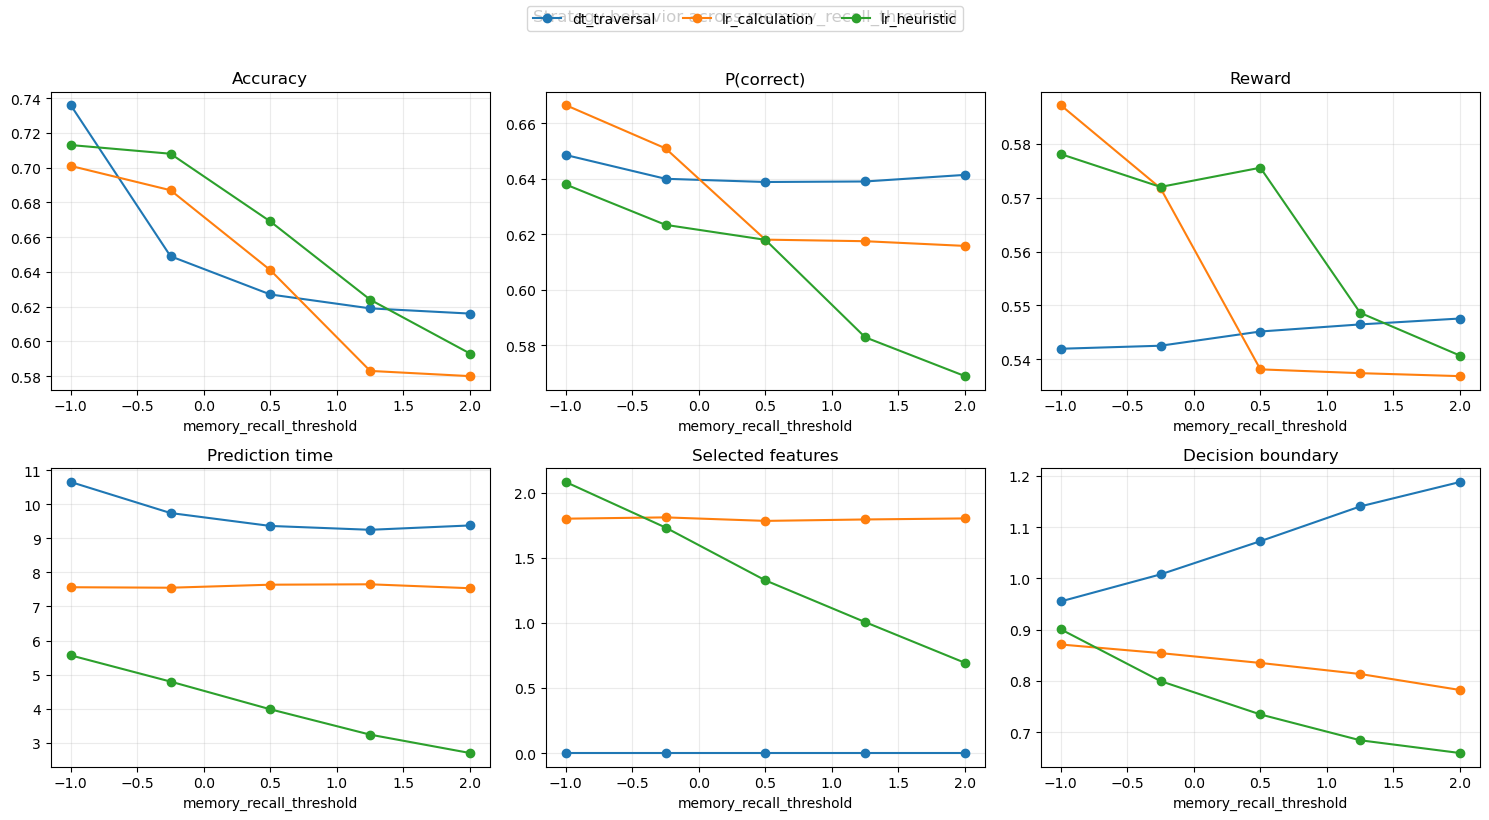

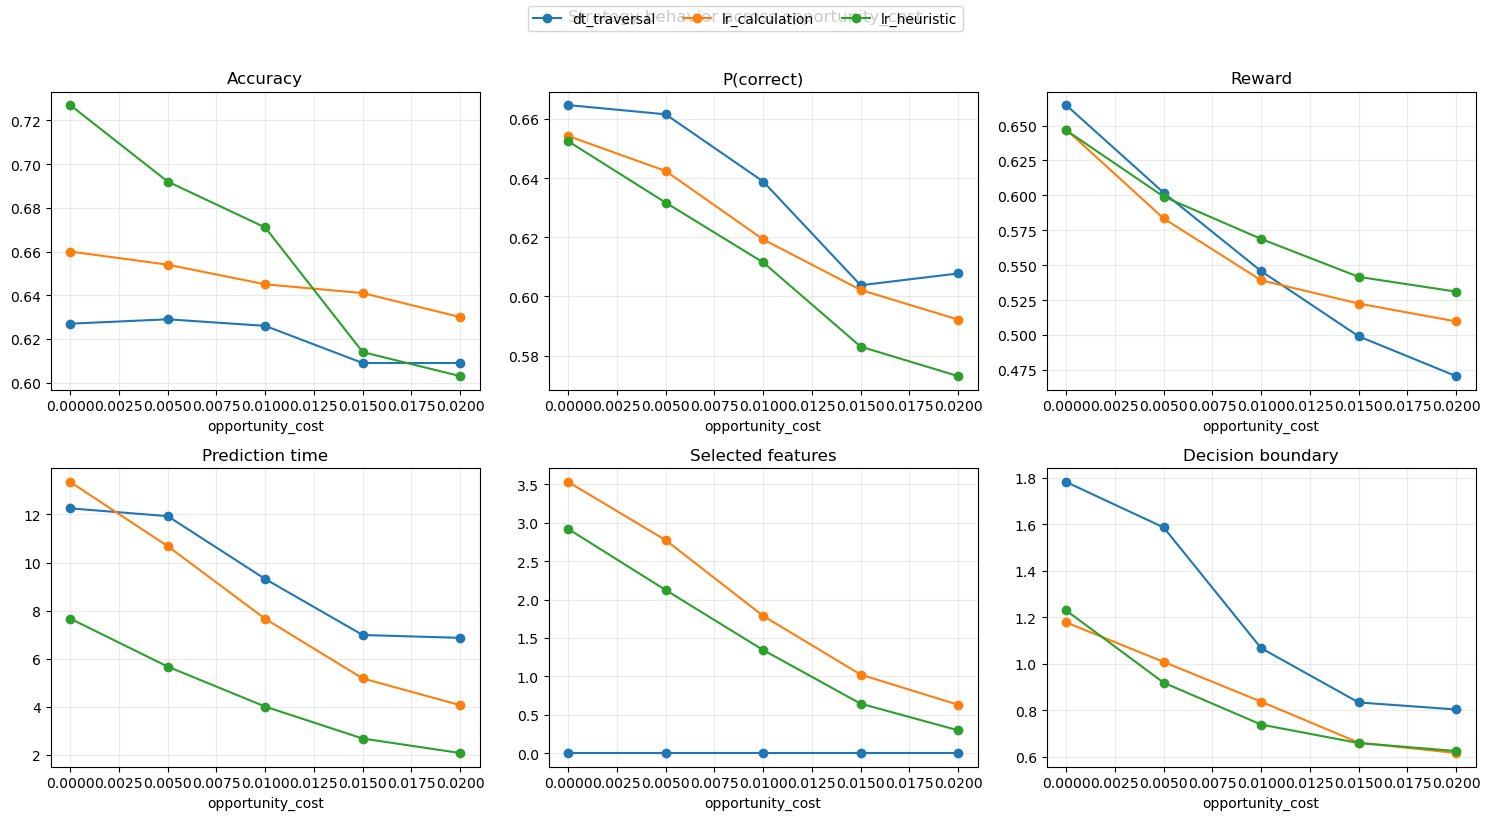

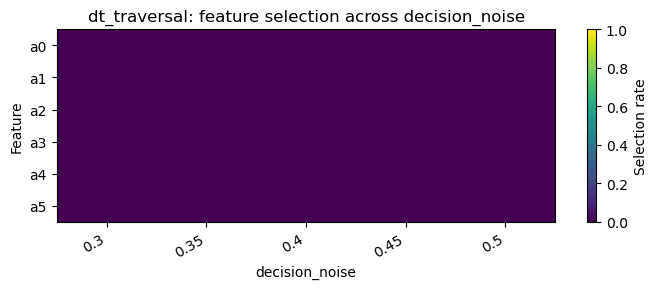

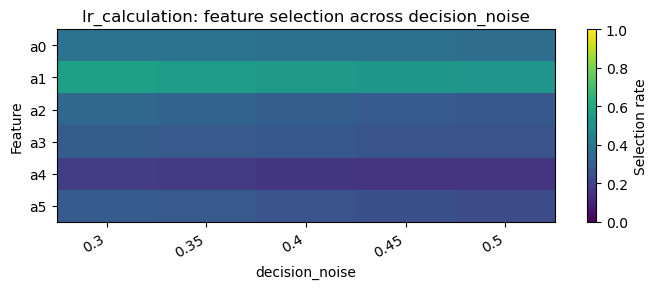

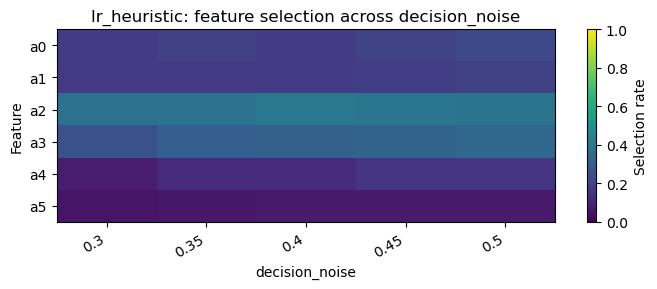

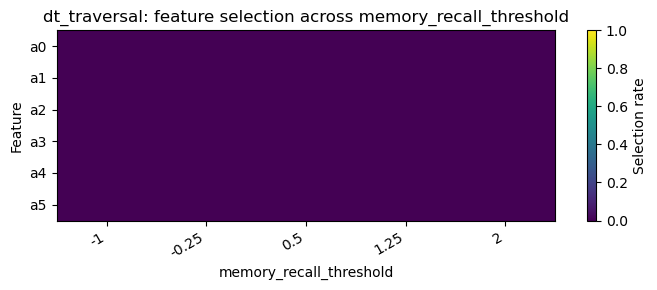

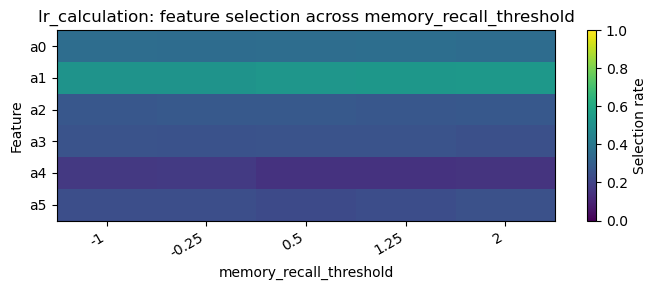

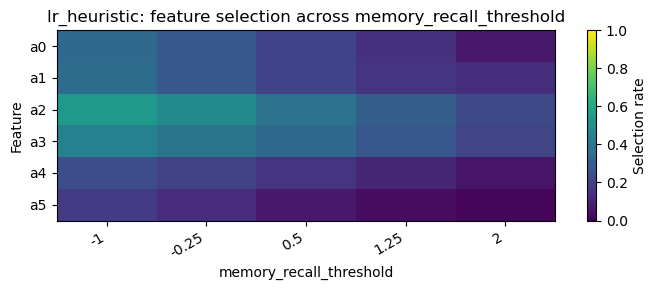

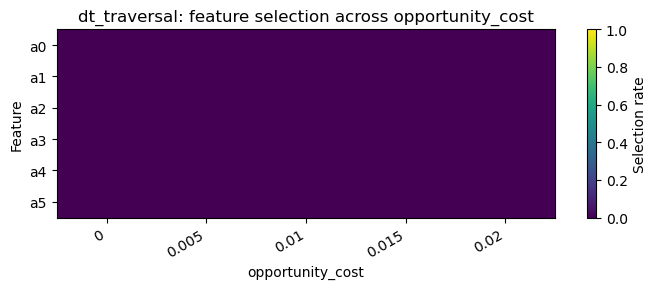

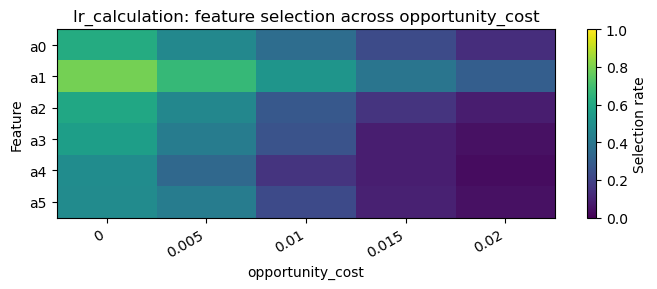

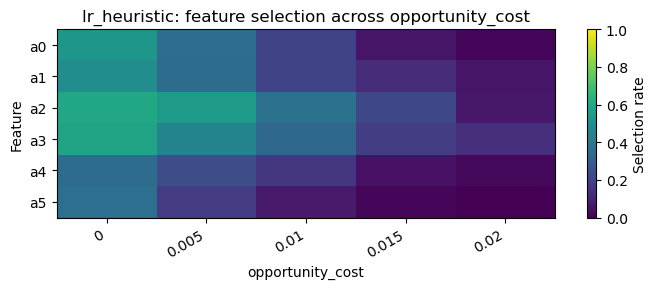

In [ ]:
sweep_figures = plot_parameter_sweep(
    sweep_df,
    output_dir=sweep_dir / "plots",
    show=True,
)
print(f"Saved {len(sweep_figures)} sweep plot(s) to {sweep_dir / 'plots'}")
